In [2]:
# Ex 2.2 Inverse Problems in Earth and Space Physics
# C. Finlay and Mikkel Otzen, DTU Space
# ballistical curve, Asters Example 2.1 p 32

In [3]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

In [4]:
t = np.arange(1,10+1)
d = np.array([109.4, 187.5, 267.5, 331.9, 386.1, 428.4, 452.2, 498.1, 512.3, 513.0])

# model: d = m_0 + m_1*t + 1/2*m_2*t^2
G = np.array([np.ones(len(t)), t, .5*t**2]).T

In [5]:
G

array([[ 1. ,  1. ,  0.5],
       [ 1. ,  2. ,  2. ],
       [ 1. ,  3. ,  4.5],
       [ 1. ,  4. ,  8. ],
       [ 1. ,  5. , 12.5],
       [ 1. ,  6. , 18. ],
       [ 1. ,  7. , 24.5],
       [ 1. ,  8. , 32. ],
       [ 1. ,  9. , 40.5],
       [ 1. , 10. , 50. ]])

In [ ]:
# LS soloution
#m_LS = np.linalg.lstsq(G, d, rcond=None)[0]  # Alternative using built in least sq solve     
G_tG=G.T@G   # G.T G lhs matrix for linear model, including weights
G_td=G.T@d       # G.T d rhs vector for linear model, including weights
m_LS = np.linalg.solve(G_tG, G_td)   #  solves (G^T G) m = G^T d

print("m_LS: ", m_LS)

d_model_LS = G@m_LS

m_LS:  [16.40833333 96.97128788 -9.40833333]


In [7]:
# Add outlier
d[3] = 631.9

#m_LS_out = np.linalg.lstsq(G, d, rcond=None)[0] 
G_td=G.T@d       # G.T d rhs vector for linear model, including weights
m_LS_out = np.linalg.solve(G_tG, G_td)   #  solves (G^T G) m = G^T d

print("m_LS_out: ", m_LS_out)

d_model_LS_out = G@m_LS_out

m_LS_out:  [  1.40833333 129.01674242 -16.22651515]


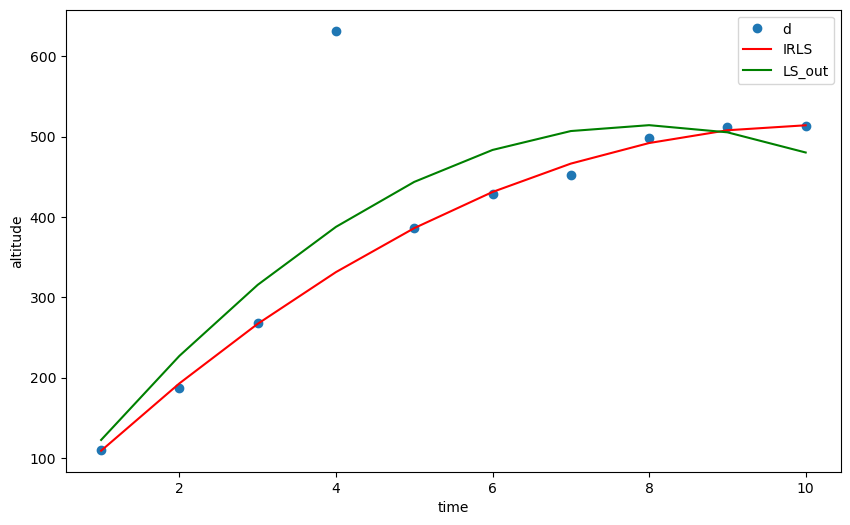

In [ ]:
# inversion using IRLS
c = 1.5
sigma = 1
niter=20
#sigma=np.sqrt(1/len(d)*np.sum((d-d_model_LS_out)**2)) # if use rms

w = np.ones(len(d));
ones_vect = np.ones(d.shape)

for i in np.arange(1,niter+1):
    W = np.diag(w)
    G_tWG=G.T@W@G   # G.T W G lhs matrix for linear model, including weights
    G_tWd=G.T@W@d       # G.T W d rhs vector for linear model, including weights
    m_IRLS = np.linalg.solve(G_tWG, G_tWd)   #  solves (G^T W G) m = G^T W d
    d_model_IRLS = G@m_IRLS
    epsilon = (d - d_model_IRLS)/sigma
    w = np.min([c/abs(epsilon),ones_vect],axis=0)
    
plt.figure(figsize=(10,6))
plt.plot(t, d, 'o', t, d_model_IRLS, 'r', t, d_model_LS_out, 'g')
plt.xlabel('time')
plt.ylabel('altitude')
plt.legend(("d","IRLS","LS_out"))

In [9]:
w

array([1.        , 0.28606517, 1.        , 0.00499065, 1.        ,
       0.55493646, 0.10545032, 0.2474895 , 0.34453443, 1.        ])